# 20251209 Analysis

Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

# Surface a failed install here, rather than as a confusing ModuleNotFoundError
# in the import cell below.
import importlib.metadata as md
assert md.version("nucleus-cdk") == "0.5.0rc2", f"got {md.version('nucleus-cdk')}"

%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

import warnings
warnings.filterwarnings('ignore')

# Set up plotting
pr.plot_setup()

## Load Data

In [2]:
# Specify file paths
data_file = "20251209-140756-cytation5-pure-timecourse-plamGFP-deGFP--biotek-cdk.txt"
platemap_file = "20251209-ClpXP.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Experiment,Name,CP
0,0 days 00:00:00,C1,848536,C,1,plamGFP-deGFP,Plate 1,2025-12-09 16:24:03,ClpXP,4 uM ClpP protein + 2.1 uM deGFP-ssRA protein ...,1
1,0 days 00:05:00,C1,684424,C,1,plamGFP-deGFP,Plate 1,2025-12-09 16:29:03,ClpXP,4 uM ClpP protein + 2.1 uM deGFP-ssRA protein ...,1
2,0 days 00:10:00,C1,633326,C,1,plamGFP-deGFP,Plate 1,2025-12-09 16:34:03,ClpXP,4 uM ClpP protein + 2.1 uM deGFP-ssRA protein ...,1
3,0 days 00:15:00,C1,612858,C,1,plamGFP-deGFP,Plate 1,2025-12-09 16:39:03,ClpXP,4 uM ClpP protein + 2.1 uM deGFP-ssRA protein ...,1
4,0 days 00:20:00,C1,607842,C,1,plamGFP-deGFP,Plate 1,2025-12-09 16:44:03,ClpXP,4 uM ClpP protein + 2.1 uM deGFP-ssRA protein ...,1


## Plot Raw Curves

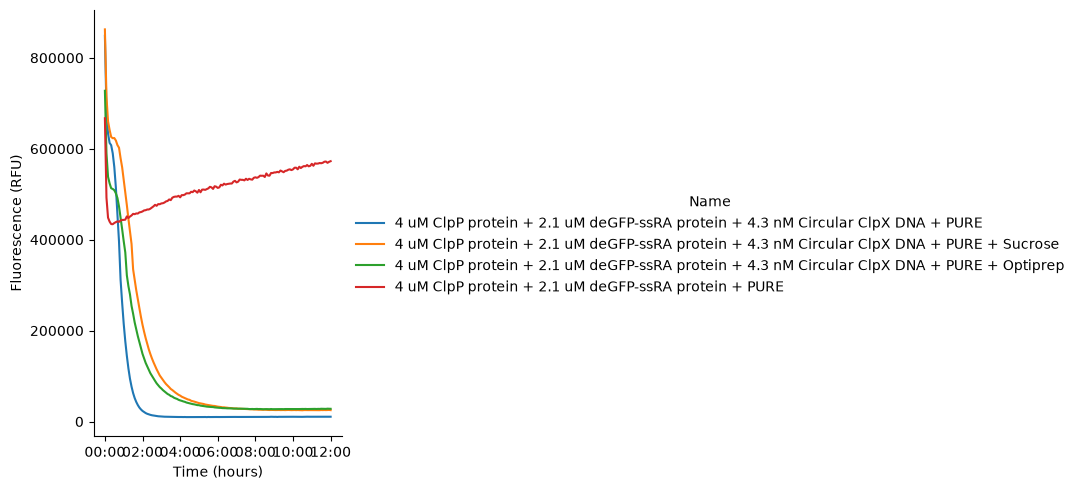

In [3]:
#| label: 20251209-kinetics

g = pr.plot_curves(data=data)